# Week 2 Deliverable: EDA + Preprocessing

## Team: MachineLearners

### Team Members

* Kalmurat Nurzhan 24B031138
* Elshibai Ulzhalgas 24B031019
* Makishev Yersultan 24B031870
* Almas Salim 22B030433

## Objective

The goal of this notebook is to explore the Telco Customer Churn dataset, identify patterns related to customer behavior, handle missing values, and prepare the data for machine learning models.

## Prediction Task

Target variable: `Churn`
This is a **classification problem**, where we predict whether a customer will leave the company.

## Hypothesis

We hypothesize that customers with month-to-month contracts and higher monthly charges are more likely to churn compared to customers with long-term contracts and lower charges.


---

## Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ModuleNotFoundError: No module named 'matplotlib'

## Load dataset

The dataset contains 7043 customers and multiple features including demographic, service, and billing information. The target variable is `Churn`, which indicates whether the customer left the company. Some columns such as `TotalCharges` contain non-numeric values and require cleaning before analysis.

In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")

# FIX DATA
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

## 1. Dataset Overview
We begin by examining the dataset structure, data types, missing values, and summary statistics.

In [ ]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

display(df.describe())

Shape: (7043, 21)

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


---

## 2. Visualisations (6)

<b>1) Histogram (MonthlyCharges)

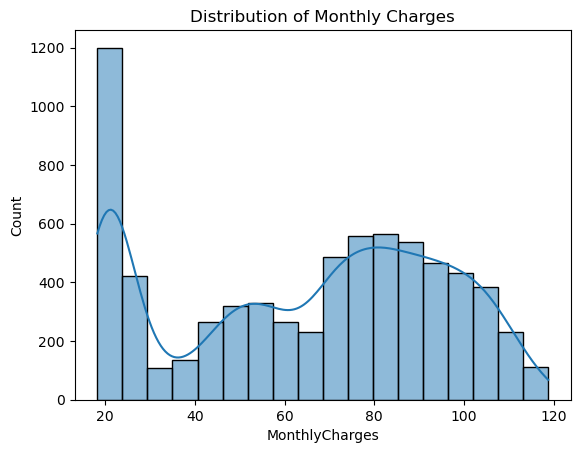

In [ ]:
sns.histplot(df["MonthlyCharges"], kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

Monthly charges are spread across a wide range, with a slight concentration in mid to high values. Higher charges may be associated with increased churn, supporting our hypothesis.

<b>2) Boxplot (MonthlyCharges vs Churn)

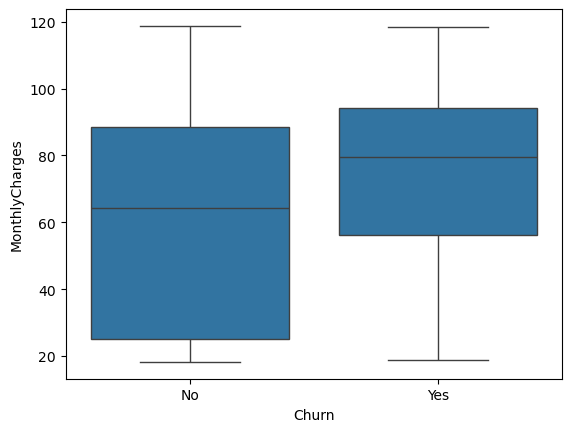

In [ ]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.show()

Customers who churn tend to have higher monthly charges on average. This supports our hypothesis that higher cost may lead to dissatisfaction and churn.

<b>3) Countplot (Contract vs Churn)

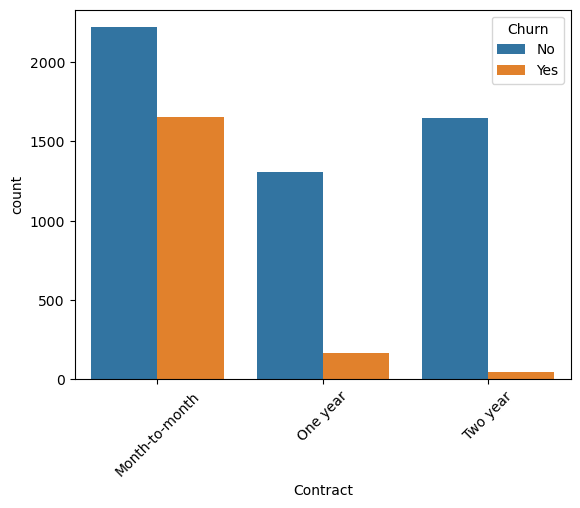

In [ ]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.xticks(rotation=45)
plt.show()

Customers with month-to-month contracts show significantly higher churn rates compared to those with longer-term contracts, strongly supporting our hypothesis.

<b>4. Histogram (tenure)

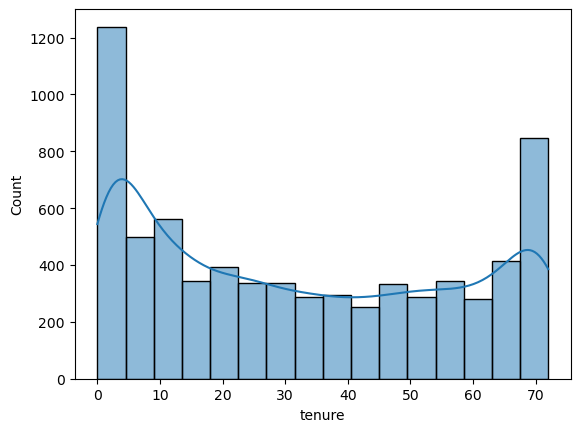

In [ ]:
sns.histplot(df["tenure"], kde=True)
plt.show()

Customers with short tenure are more common among churned users. This suggests that new customers are more likely to leave early.

<b>5. Correlation heatmap

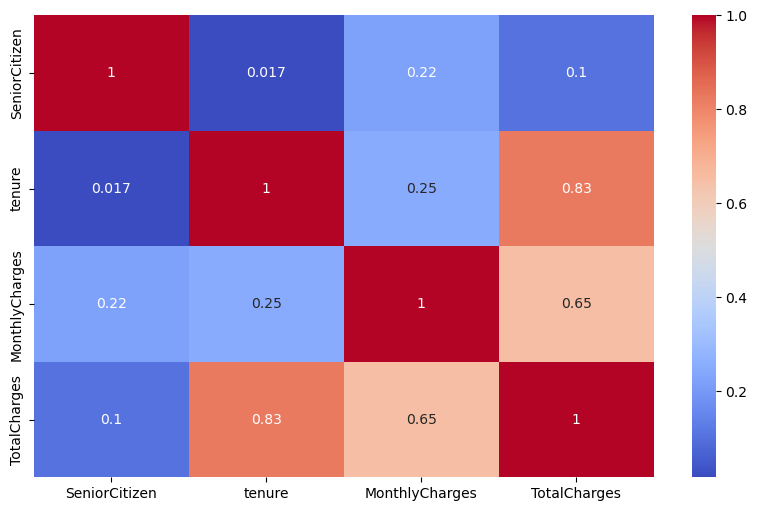

In [ ]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

The strongest correlations are between `tenure` and `TotalCharges`, and between `MonthlyCharges` and `TotalCharges`, which is expected because total charges accumulate over time and depend on the monthly bill. In relation to churn, customers with shorter tenure and higher monthly charges appear more likely to leave, which supports our hypothesis. These variables are therefore likely to be important predictors in the classification model.

<b>6. PaymentMethod vs Churn

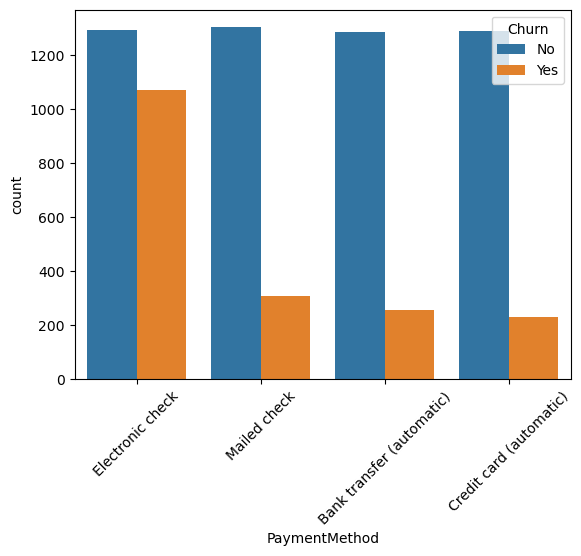

In [ ]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=45)
plt.show()

Certain payment methods show higher churn rates, which may indicate differences in customer reliability or satisfaction levels.

---

## 3. Missing Value Handling
We identify missing values and handle them using column-specific strategies instead of a blanket drop.

In [ ]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [ ]:
# Only TotalCharges has missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

The `TotalCharges` column contained missing values due to incorrect data type conversion. Since it is an important numerical feature, we imputed missing values using the median, which is robust to outliers.

Drop useless column

In [ ]:
df.drop("customerID", axis=1, inplace=True)

The `customerID` column is an identifier and does not contribute to prediction, so it was removed.

<b>Encoding

In [ ]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [ ]:
df = pd.get_dummies(df, drop_first=True)

We used one-hot encoding for categorical variables because most of them are nominal and have relatively low cardinality. Since our planned models include standard machine learning classifiers that work with numerical input, one-hot encoding is appropriate because it avoids creating false ordinal relationships between categories.

The categorical variables have relatively low cardinality, making one-hot encoding an efficient and suitable approach.

<b>Feature engineering

In [ ]:
df["AvgCharge"] = df["TotalCharges"] / (df["tenure"] + 1)

We created a new feature `AvgCharge`, which represents average spending per month. This may better capture customer behavior than total charges alone.

In [ ]:
#df.to_csv("clean_telco_data.csv", index=False)

---

## Conclusion

In this notebook, we explored the Telco Customer Churn dataset and identified key factors influencing customer churn. We visualized important relationships, handled missing values using appropriate strategies, encoded categorical variables, and engineered new features. Finally, we prepared the dataset for modelling by splitting it into training and test sets and applying scaling. This ensures a clean and reliable input for machine learning models.

---

<b>Split

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Scaling

scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=np.number).columns

#We used StandardScaler to normalize numerical features. Importantly, the scaler was fitted only on the training data to avoid data leakage, and then applied to the test data.



X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])



#X_train.to_csv("X_train.csv", index=False)
#X_test.to_csv("X_test.csv", index=False)
#y_train.to_csv("y_train.csv", index=False)
#y_test.to_csv("y_test.csv", index=False)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 31)
X_test shape: (1409, 31)
y_train shape: (5634,)
y_test shape: (1409,)


In [ ]:
df.to_csv("clean_telco_data.csv", index=False)

X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)